# EduSense — Ottawa Traffic Collisions
## 01 · Analyse exploratoire (EDA)

**Notebook autonome** — repart de `Traffic_Collision_Data.csv` et applique  
le preprocessing complet avant les visualisations.

**Input :** `Traffic_Collision_Data.csv`

### 0 · Imports & preprocessing

In [15]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.gridspec import GridSpec

plt.rcParams.update({
    'figure.facecolor':'white','axes.facecolor':'#f8f8f6',
    'axes.grid':True,'grid.color':'white','grid.linewidth':0.8,
    'axes.spines.top':False,'axes.spines.right':False,
    'axes.titlesize':12,'axes.labelsize':10,
    'xtick.labelsize':9,'ytick.labelsize':9,
})
PALETTE = {
    'fatal':'#C0392B','severe':'#E67E22','blessure':'#F1C40F',
    'materiel':'#3498DB','hiver':'#8E44AD','vuln':'#27AE60','neutral':'#7F8C8D',
}

In [16]:
import pandas as pd
import numpy as np
from pyproj import Transformer
import warnings
warnings.filterwarnings('ignore')

# ── Chargement ──────────────────────────────────────────────────────────────
df = pd.read_csv('Traffic_Collision_Data.csv')
raw_count = len(df)

# ── Nettoyage géographique ──────────────────────────────────────────────────
df = df[df['Lat'] != 0.0].copy()
df = df[df['Lat'].between(44.9, 45.6) & df['Long'].between(-76.4, -75.2)].copy()

transformer = Transformer.from_crs("EPSG:4326", "EPSG:32618", always_xy=True)
df['utm_x'], df['utm_y'] = transformer.transform(df['Long'].values, df['Lat'].values)

# ── Nettoyage temporel ──────────────────────────────────────────────────────
df['Accident_Date'] = pd.to_datetime(df['Accident_Date'], format='%m/%d/%Y', errors='coerce')
df = df[df['Accident_Date'].notna()].copy()
df['month']       = df['Accident_Date'].dt.month
df['day_of_week'] = df['Accident_Date'].dt.dayofweek
df['quarter']     = df['Accident_Date'].dt.quarter
df['saison']      = df['month'].map({
    12:'Hiver',1:'Hiver',2:'Hiver',
    3:'Printemps',4:'Printemps',5:'Printemps',
    6:'Été',7:'Été',8:'Été',
    9:'Automne',10:'Automne',11:'Automne'})
df['is_weekend']  = df['day_of_week'].isin([5,6]).astype(int)

# ── Variables catégorielles ─────────────────────────────────────────────────
def parse_coded(series):
    code  = series.str.extract(r'^(\d+)')[0].astype(float)
    label = series.str.extract(r'^\d+\s*-\s*(.+)$')[0].str.strip()
    return code, label

coded_cols = {
    'Classification_Of_Accident':'classif',
    'Initial_Impact_Type':'impact',
    'Road_1_Surface_Condition':'surface',
    'Environment_Condition_1':'meteo',
    'Light':'lumiere',
    'Traffic_Control':'controle',
}
for orig, prefix in coded_cols.items():
    code, label = parse_coded(df[orig].fillna('00 - Unknown'))
    df[f'{prefix}_code']  = code
    df[f'{prefix}_label'] = label
    for suf in ['_label','_code']:
        col = f'{prefix}{suf}'
        if df[col].isna().any():
            df[col] = df[col].fillna(df[col].mode()[0])

# ── Gravité ─────────────────────────────────────────────────────────────────
df['severity_score'] = df['Classification_Of_Accident'].map({
    '03 - P.D. only':0,'04 - Non-reportable':0,
    '02 - Non-fatal injury':1,'01 - Fatal injury':2
}).fillna(0).astype(int)
df['injury_rank'] = df['Max_injury'].map({'Minimal':1,'Minor':2,'Major':3,'Fatal':4})
df['is_severe']   = (
    (df['severity_score']==2) | (df['injury_rank'].isin([3,4])).fillna(False)
).astype(int)

# ── Usagers vulnérables ─────────────────────────────────────────────────────
for col in ['num_of_pedestrians','num_of_bicycles','num_of_motorcycles']:
    df[col] = df[col].fillna(0).astype(int)
df['num_of_vehicles']  = df['num_of_vehicles'].fillna(df['num_of_vehicles'].median()).round().astype(int)
df['has_pedestrian']   = (df['num_of_pedestrians'] > 0).astype(int)
df['has_bicycle']      = (df['num_of_bicycles']    > 0).astype(int)
df['has_motorcycle']   = (df['num_of_motorcycles'] > 0).astype(int)
df['has_vulnerable']   = ((df['has_pedestrian'] | df['has_bicycle'] | df['has_motorcycle']) > 0).astype(int)

# ── Features clustering ─────────────────────────────────────────────────────
df['is_winter_surface']    = df['surface_label'].isin(['Loose snow','Packed snow','Ice','Slush']).astype(int)
df['is_winter_weather']    = df['meteo_label'].isin(['Snow','Freezing Rain','Drifting Snow']).astype(int)
df['is_winter_conditions'] = ((df['is_winter_surface'] | df['is_winter_weather']) > 0).astype(int)
df['is_dark']              = (df['lumiere_label'] == 'Dark').astype(int)
df['is_low_light']         = df['lumiere_label'].isin(['Dark','Dusk','Dawn']).astype(int)
df['has_signal']           = (df['controle_label'] == 'Traffic signal').astype(int)
df['no_control']           = (df['controle_label'] == 'No control').astype(int)
df['impact_simple']        = df['impact_label'].map({
    'Rear end':'arriere','Angle':'angle','Sideswipe':'lateral',
    'Turning movement':'virage','SMV other':'smv',
    'SMV unattended vehicle':'smv','Approaching':'face_a_face','Other':'autre'
}).fillna('autre')

print(f"Dataset prêt : {len(df):,} lignes × {df.shape[1]} colonnes")
print(f"  Supprimées : {raw_count - len(df)} (coordonnées invalides)")

Dataset prêt : 94,334 lignes × 62 colonnes
  Supprimées : 72 (coordonnées invalides)


### Figure 1 — Vue d'ensemble

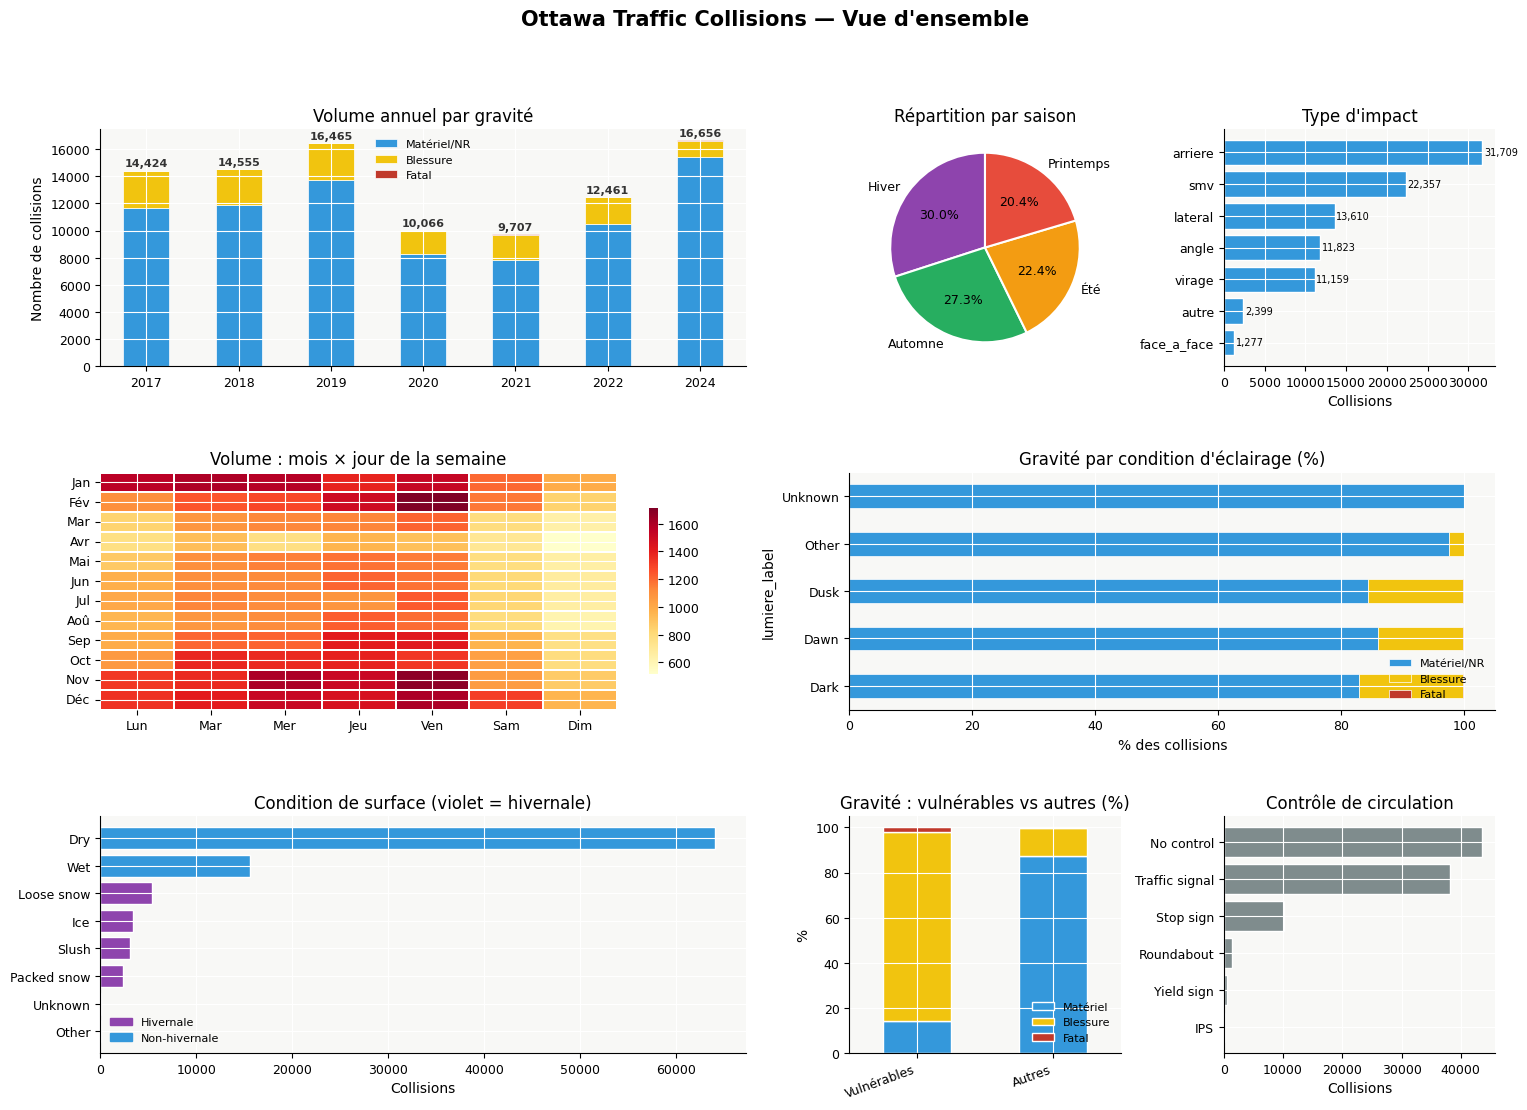

In [24]:
fig = plt.figure(figsize=(18,12))
fig.suptitle("Ottawa Traffic Collisions — Vue d'ensemble", fontsize=15, fontweight='bold', y=0.98)
gs = GridSpec(3, 4, figure=fig, hspace=0.45, wspace=0.38)

# 1A — Volume annuel par gravité
ax1a = fig.add_subplot(gs[0,:2])
yearly = df.groupby(['Accident_Year','severity_score']).size().unstack(fill_value=0)
yearly.columns = ['Matériel/NR','Blessure','Fatal']
yearly.plot(kind='bar', stacked=True, ax=ax1a,
            color=[PALETTE['materiel'],PALETTE['blessure'],PALETTE['fatal']],
            edgecolor='white', linewidth=0.5)
ax1a.set_title("Volume annuel par gravité")
ax1a.set_xlabel("")
ax1a.set_ylabel("Nombre de collisions")
ax1a.set_xticklabels(yearly.index, rotation=0)
ax1a.legend(frameon=False, fontsize=8)
for i,(yr,row) in enumerate(yearly.iterrows()):
    ax1a.text(i, row.sum()+150, f"{row.sum():,}", ha='center', va='bottom', fontsize=8, fontweight='bold', color='#333')

# 1B — Répartition par saison
ax1b = fig.add_subplot(gs[0,2])
sc = df['saison'].value_counts()
ax1b.pie(sc.values, labels=sc.index,
         colors=['#8E44AD','#27AE60','#F39C12','#E74C3C'],
         autopct='%1.1f%%', startangle=90,
         wedgeprops={'edgecolor':'white','linewidth':1.5},
         textprops={'fontsize':9})
ax1b.set_title("Répartition par saison")

# 1C — Type d'impact
ax1c = fig.add_subplot(gs[0,3])
ic = df['impact_simple'].value_counts()
ax1c.barh(ic.index[::-1], ic.values[::-1], color=PALETTE['materiel'], edgecolor='white')
ax1c.set_title("Type d'impact")
ax1c.set_xlabel("Collisions")
for i,(idx,val) in enumerate(zip(ic.index[::-1],ic.values[::-1])):
    ax1c.text(val+200, i, f"{val:,}", va='center', fontsize=7)

# 1D — Heatmap volume mois × jour
ax1d = fig.add_subplot(gs[1,:2])
hd = df.groupby(['month','day_of_week']).size().unstack(fill_value=0)
hd.columns = ['Lun','Mar','Mer','Jeu','Ven','Sam','Dim']
hd.index   = ['Jan','Fév','Mar','Avr','Mai','Jun','Jul','Aoû','Sep','Oct','Nov','Déc']
sns.heatmap(hd, ax=ax1d, cmap='YlOrRd', linewidths=0.3, linecolor='white',
            annot=False, cbar_kws={'shrink':0.7})
ax1d.set_title("Volume : mois × jour de la semaine")

# 1E — Gravité par éclairage
ax1e = fig.add_subplot(gs[1,2:])
ls = df.groupby('lumiere_label')['severity_score'].value_counts(normalize=True).unstack(fill_value=0)*100
ls.columns = ['Matériel/NR','Blessure','Fatal']
ls = ls.loc[ls.sum(axis=1).sort_values(ascending=False).head(5).index]
ls.plot(kind='barh', stacked=True, ax=ax1e,
        color=[PALETTE['materiel'],PALETTE['blessure'],PALETTE['fatal']],
        edgecolor='white', linewidth=0.5)
ax1e.set_title("Gravité par condition d'éclairage (%)")
ax1e.set_xlabel("% des collisions")
ax1e.legend(frameon=False, fontsize=8, loc='lower right')

# 1F — Surface de chaussée
ax1f = fig.add_subplot(gs[2,:2])
surf = df['surface_label'].value_counts().head(8)
cs   = [PALETTE['hiver'] if any(w in s for w in ['snow','Snow','Ice','Slush','ice'])
        else PALETTE['materiel'] for s in surf.index]
ax1f.barh(surf.index[::-1], surf.values[::-1], color=cs[::-1], edgecolor='white')
ax1f.set_title("Condition de surface (violet = hivernale)")
ax1f.set_xlabel("Collisions")
ax1f.legend(handles=[mpatches.Patch(color=PALETTE['hiver'],label='Hivernale'),
                     mpatches.Patch(color=PALETTE['materiel'],label='Non-hivernale')],
            frameon=False, fontsize=8)

# 1G — Vulnérables vs autres
ax1g = fig.add_subplot(gs[2,2])
vd = pd.DataFrame({
    'Vulnérables': df[df['has_vulnerable']==1]['severity_score'].value_counts(normalize=True).sort_index()*100,
    'Autres':      df[df['has_vulnerable']==0]['severity_score'].value_counts(normalize=True).sort_index()*100,
}).fillna(0).T
vd.columns = ['Matériel','Blessure','Fatal']
vd.plot(kind='bar', ax=ax1g, stacked=True,
        color=[PALETTE['materiel'],PALETTE['blessure'],PALETTE['fatal']], edgecolor='white')
ax1g.set_title("Gravité : vulnérables vs autres (%)")
ax1g.set_ylabel("%")
ax1g.set_xticklabels(vd.index, rotation=20, ha='right')
ax1g.legend(frameon=False, fontsize=8)

# 1H — Contrôle de circulation
ax1h = fig.add_subplot(gs[2,3])
cc = df['controle_label'].value_counts().head(6)
ax1h.barh(cc.index[::-1], cc.values[::-1], color=PALETTE['neutral'], edgecolor='white')
ax1h.set_title("Contrôle de circulation")
ax1h.set_xlabel("Collisions")

plt.tight_layout()
plt.savefig('fig1_overview.png', dpi=150, bbox_inches='tight')
plt.show()

### Figure 2 — Analyse temporelle

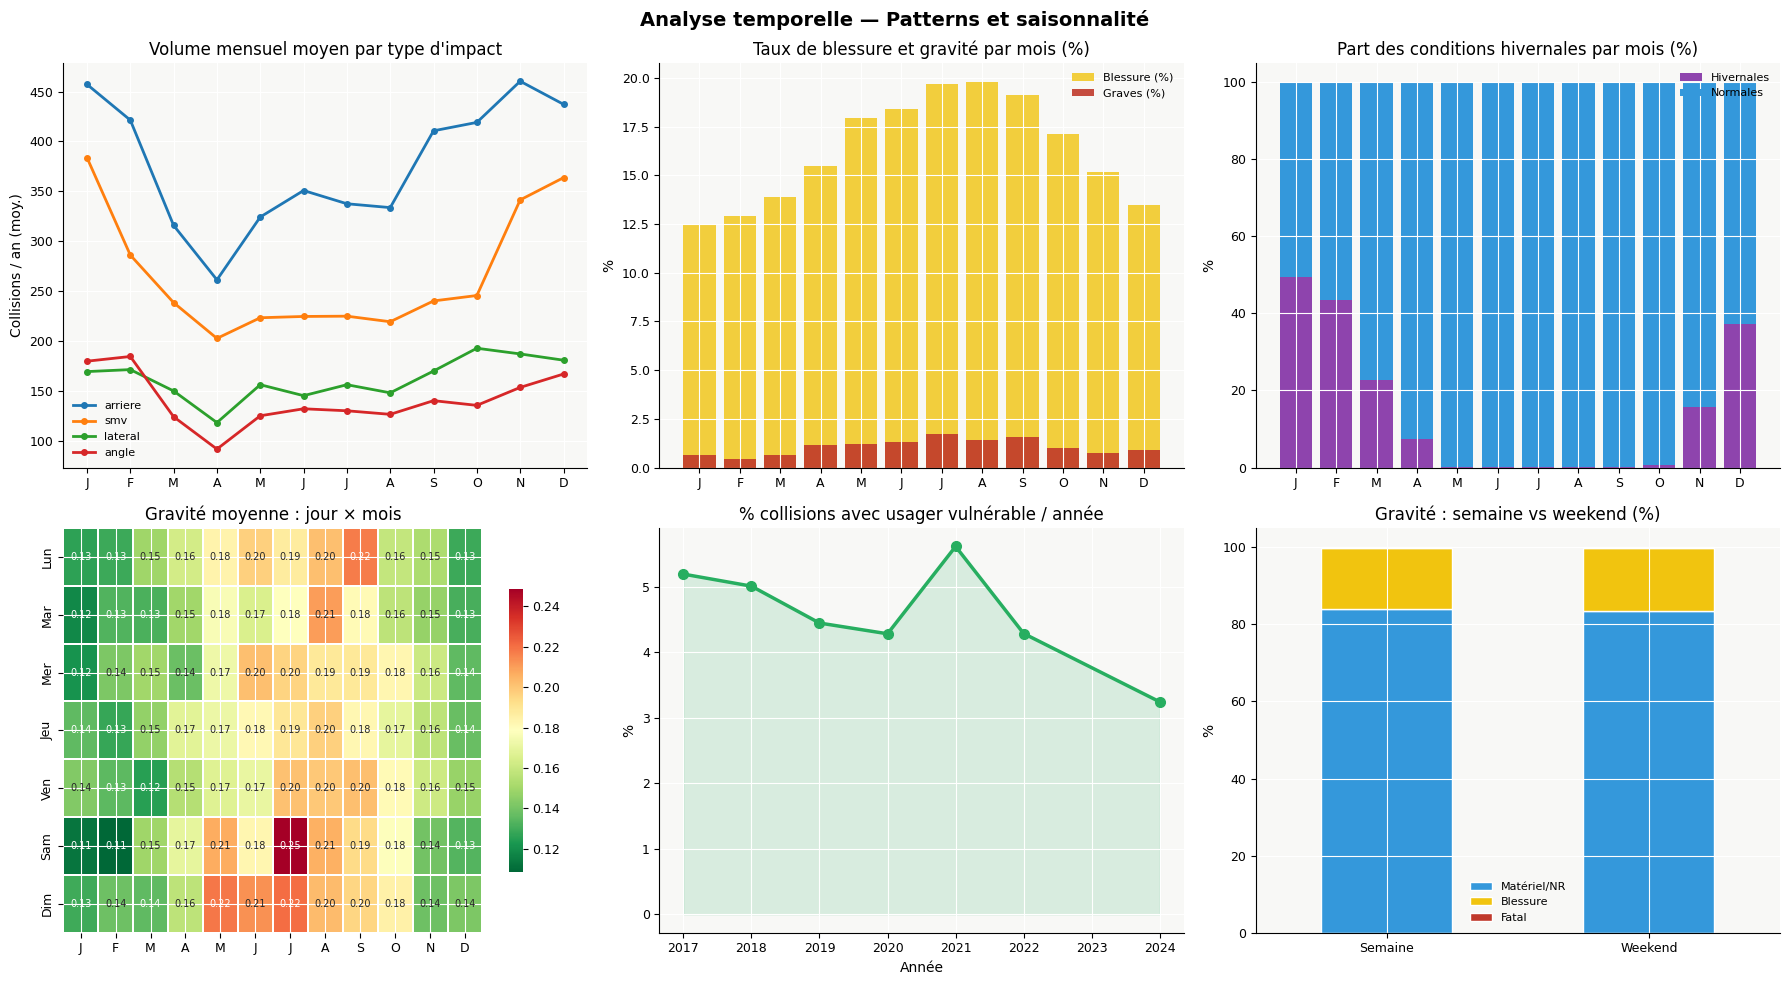

In [25]:
fig2, axes = plt.subplots(2, 3, figsize=(18,10))
fig2.suptitle("Analyse temporelle — Patterns et saisonnalité", fontsize=14, fontweight='bold')

# 2A — Volume mensuel moyen par type d'impact
ax = axes[0,0]
mt  = df.groupby(['month','impact_simple']).size().unstack(fill_value=0)
avg = mt.div(df['Accident_Year'].nunique())
for col in avg.sum().nlargest(4).index:
    ax.plot(range(1,13), avg[col], marker='o', markersize=4, linewidth=2, label=col)
ax.set_xticks(range(1,13))
ax.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
ax.set_title("Volume mensuel moyen par type d'impact")
ax.set_ylabel("Collisions / an (moy.)"); ax.legend(frameon=False, fontsize=8)

# 2B — Taux de gravité mensuel
ax = axes[0,1]
ms = df.groupby('month').agg(
    total=('severity_score','count'),
    severe=('is_severe','sum'),
    blessure=('severity_score', lambda x:(x>=1).sum())
).reset_index()
ms['pct_severe']   = ms['severe']   / ms['total'] * 100
ms['pct_blessure'] = ms['blessure'] / ms['total'] * 100
ax.bar(ms['month'], ms['pct_blessure'], color=PALETTE['blessure'], label='Blessure (%)', alpha=0.8)
ax.bar(ms['month'], ms['pct_severe'],   color=PALETTE['fatal'],    label='Graves (%)',  alpha=0.9)
ax.set_xticks(range(1,13))
ax.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
ax.set_title("Taux de blessure et gravité par mois (%)")
ax.set_ylabel("%"); ax.legend(frameon=False, fontsize=8)

# 2C — Part conditions hivernales par mois
ax = axes[0,2]
hv = df.groupby(['month','is_winter_conditions']).size().unstack(fill_value=0)
hv.columns = ['Normales','Hivernales']
hp = hv.div(hv.sum(axis=1),axis=0)*100
ax.bar(range(1,13), hp['Hivernales'], color=PALETTE['hiver'],    label='Hivernales')
ax.bar(range(1,13), hp['Normales'],   color=PALETTE['materiel'], label='Normales', bottom=hp['Hivernales'])
ax.set_xticks(range(1,13))
ax.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
ax.set_title("Part des conditions hivernales par mois (%)")
ax.set_ylabel("%"); ax.legend(frameon=False, fontsize=8)

# 2D — Heatmap gravité moyenne jour × mois
ax = axes[1,0]
sh = df.groupby(['day_of_week','month'])['severity_score'].mean().unstack()
sh.index   = ['Lun','Mar','Mer','Jeu','Ven','Sam','Dim']
sh.columns = ['J','F','M','A','M','J','J','A','S','O','N','D']
sns.heatmap(sh, ax=ax, cmap='RdYlGn_r', linewidths=0.3, linecolor='white',
            annot=True, fmt='.2f', annot_kws={'size':7}, cbar_kws={'shrink':0.7})
ax.set_title("Gravité moyenne : jour × mois")

# 2E — % collisions vulnérables par année
ax = axes[1,1]
yv = df.groupby('Accident_Year').agg(total=('has_vulnerable','count'),vuln=('has_vulnerable','sum')).reset_index()
yv['pct'] = yv['vuln']/yv['total']*100
ax.plot(yv['Accident_Year'], yv['pct'], marker='o', color=PALETTE['vuln'], linewidth=2.5, markersize=7)
ax.fill_between(yv['Accident_Year'], yv['pct'], alpha=0.15, color=PALETTE['vuln'])
ax.set_title("% collisions avec usager vulnérable / année")
ax.set_ylabel("%"); ax.set_xlabel("Année")

# 2F — Weekend vs semaine
ax = axes[1,2]
wk = df.groupby(['is_weekend','severity_score']).size().unstack(fill_value=0)
wk.index   = ['Semaine','Weekend']
wp = wk.div(wk.sum(axis=1),axis=0)*100
wp.columns = ['Matériel/NR','Blessure','Fatal']
wp.plot(kind='bar', stacked=True, ax=ax,
        color=[PALETTE['materiel'],PALETTE['blessure'],PALETTE['fatal']], edgecolor='white')
ax.set_title("Gravité : semaine vs weekend (%)")
ax.set_ylabel("%"); ax.set_xticklabels(wp.index, rotation=0)
ax.legend(frameon=False, fontsize=8)

plt.tight_layout()
plt.savefig('fig2_temporal.png', dpi=150, bbox_inches='tight')
plt.show()

### Figure 3 — Distribution géographique

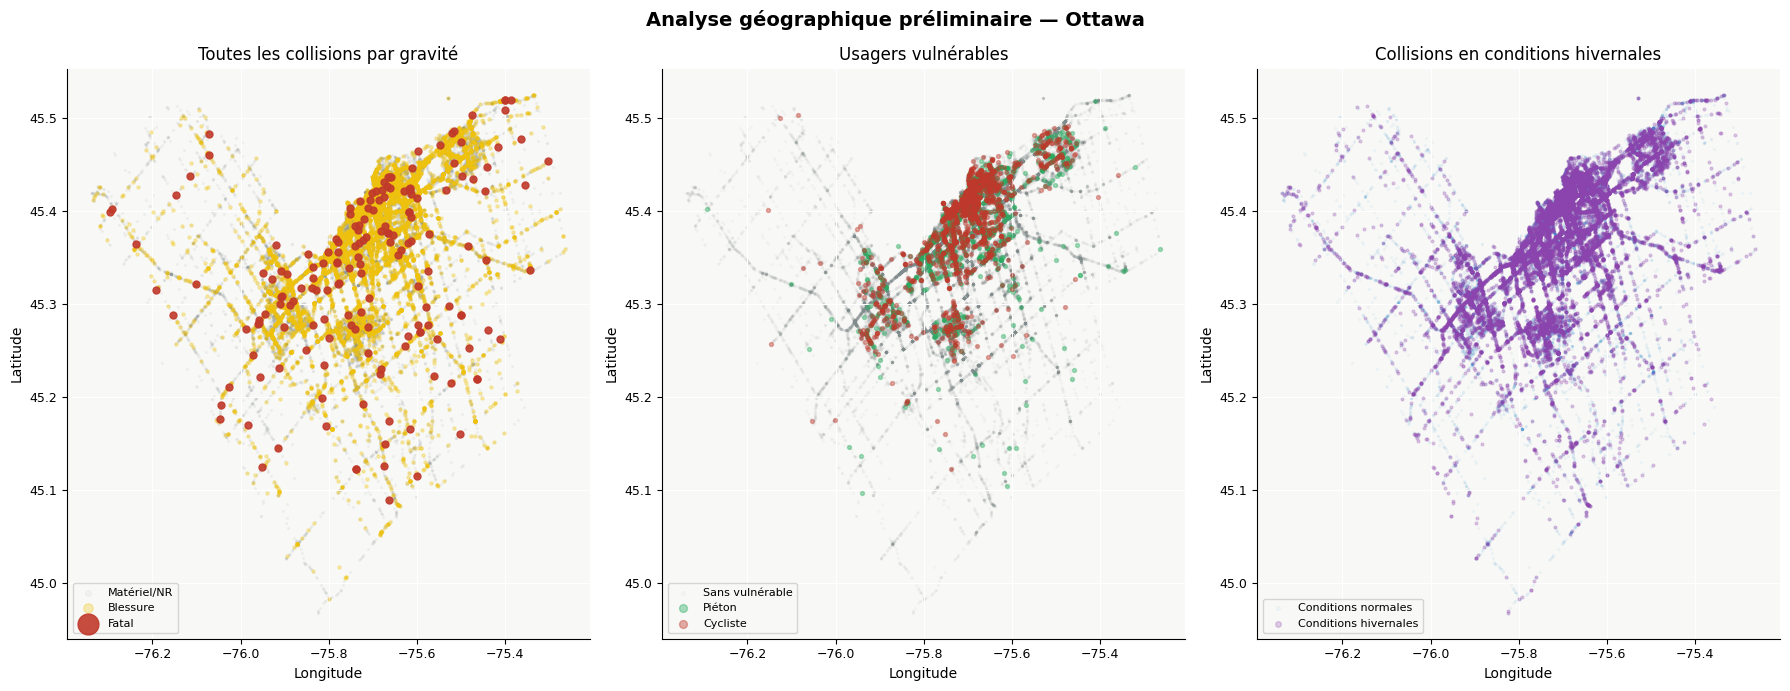

In [26]:
fig3, axes = plt.subplots(1, 3, figsize=(18,7))
fig3.suptitle("Analyse géographique préliminaire — Ottawa", fontsize=14, fontweight='bold')

ax = axes[0]
for sev, color, alpha, size, zorder, label in [
    (0,PALETTE['neutral'],0.05,2,1,'Matériel/NR'),
    (1,PALETTE['blessure'],0.30,5,2,'Blessure'),
    (2,PALETTE['fatal'],0.90,25,3,'Fatal'),
]:
    sub = df[df['severity_score']==sev]
    ax.scatter(sub['Long'], sub['Lat'], c=color, alpha=alpha, s=size, zorder=zorder, label=label)
ax.set_title("Toutes les collisions par gravité")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.legend(frameon=True, fontsize=8, markerscale=3)

ax = axes[1]
ax.scatter(df[df['has_vulnerable']==0]['Long'], df[df['has_vulnerable']==0]['Lat'],
           c=PALETTE['neutral'], alpha=0.03, s=2, label='Sans vulnérable')
ax.scatter(df[df['has_pedestrian']==1]['Long'], df[df['has_pedestrian']==1]['Lat'],
           c=PALETTE['vuln'],  alpha=0.4, s=8, label='Piéton',   zorder=2)
ax.scatter(df[df['has_bicycle']==1]['Long'], df[df['has_bicycle']==1]['Lat'],
           c=PALETTE['fatal'], alpha=0.4, s=8, label='Cycliste', zorder=3)
ax.set_title("Usagers vulnérables")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.legend(frameon=True, fontsize=8, markerscale=2)

ax = axes[2]
ax.scatter(df[df['is_winter_conditions']==0]['Long'], df[df['is_winter_conditions']==0]['Lat'],
           c=PALETTE['materiel'], alpha=0.04, s=2, label='Conditions normales')
ax.scatter(df[df['is_winter_conditions']==1]['Long'], df[df['is_winter_conditions']==1]['Lat'],
           c=PALETTE['hiver'],    alpha=0.25, s=4, label='Conditions hivernales', zorder=2)
ax.set_title("Collisions en conditions hivernales")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.legend(frameon=True, fontsize=8, markerscale=2)

plt.tight_layout()
plt.savefig('fig3_geo_preview.png', dpi=150, bbox_inches='tight')
plt.show()

### Figure 4 — Profil des usagers vulnérables

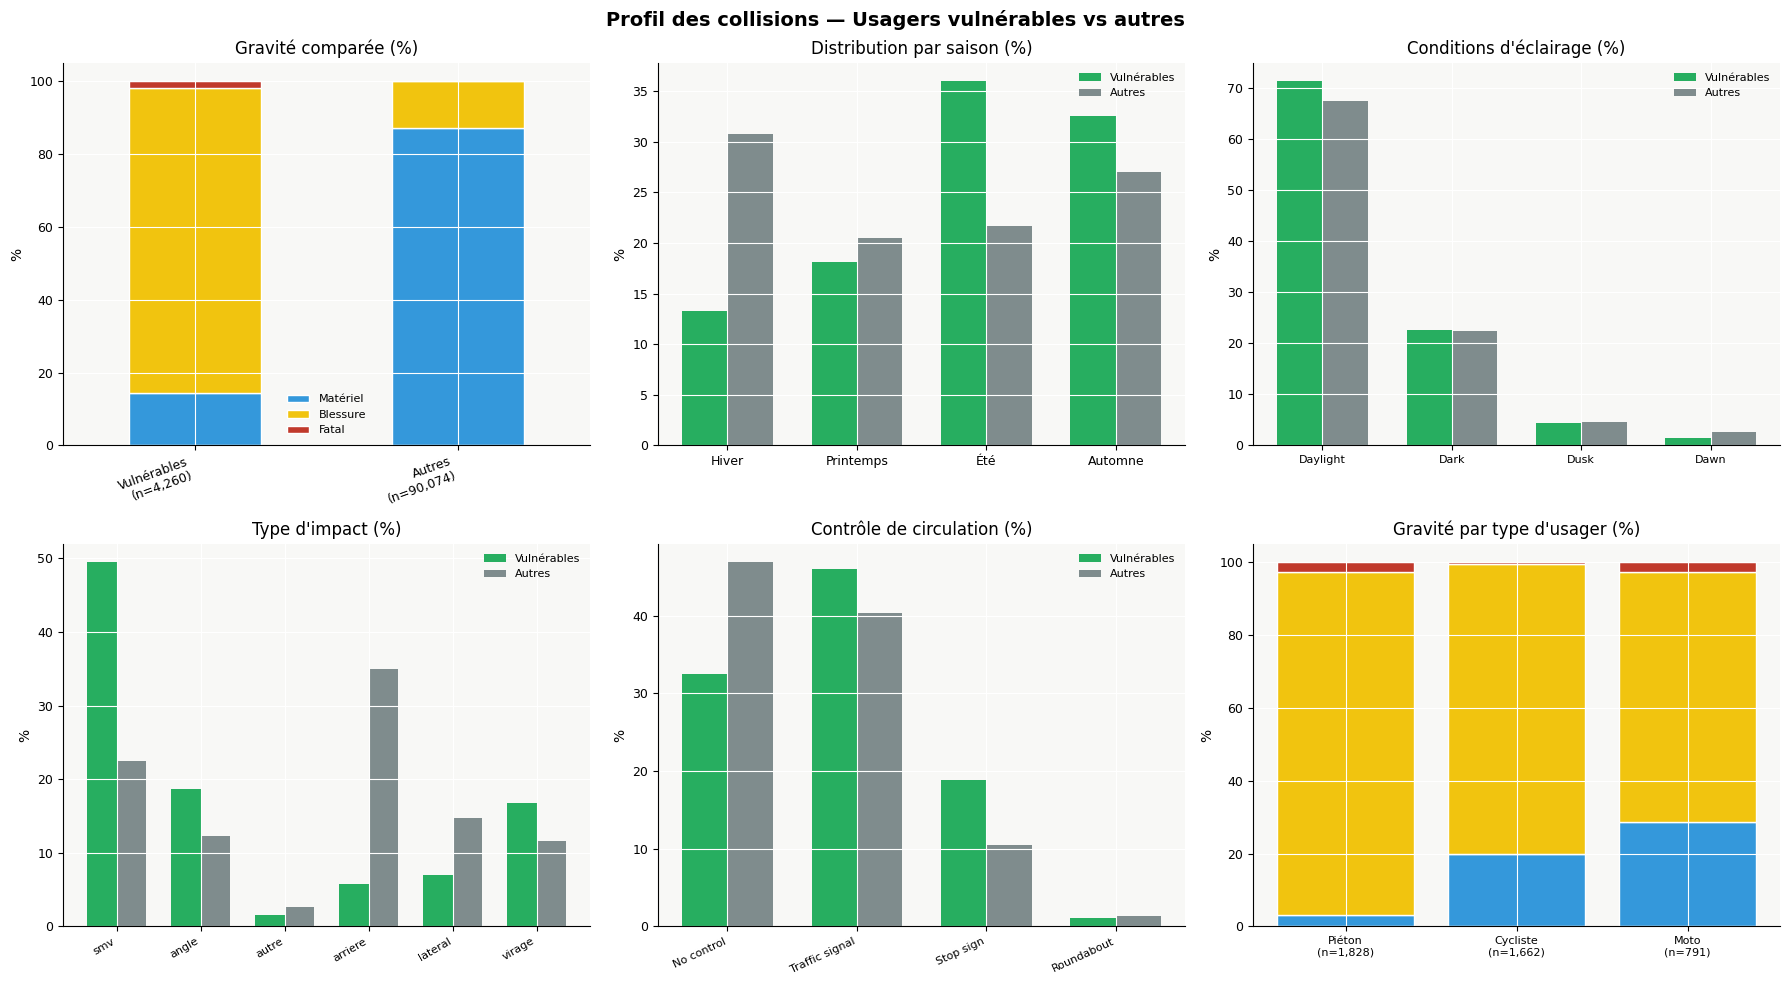

In [27]:
fig4, axes = plt.subplots(2, 3, figsize=(18,10))
fig4.suptitle("Profil des collisions — Usagers vulnérables vs autres", fontsize=14, fontweight='bold')

df_vuln  = df[df['has_vulnerable']==1]
df_autre = df[df['has_vulnerable']==0]
w = 0.35

ax = axes[0,0]
comp = pd.DataFrame({
    f'Vulnérables\n(n={len(df_vuln):,})':
        df_vuln['severity_score'].value_counts(normalize=True).sort_index()*100,
    f'Autres\n(n={len(df_autre):,})':
        df_autre['severity_score'].value_counts(normalize=True).sort_index()*100,
}).fillna(0).T
comp.columns = ['Matériel','Blessure','Fatal']
comp.plot(kind='bar',ax=ax,stacked=True,
          color=[PALETTE['materiel'],PALETTE['blessure'],PALETTE['fatal']],edgecolor='white')
ax.set_title("Gravité comparée (%)"); ax.set_ylabel("%")
ax.set_xticklabels(comp.index, rotation=20, ha='right')
ax.legend(frameon=False, fontsize=8)

ax = axes[0,1]
saisons = ['Hiver','Printemps','Été','Automne']
vs = df_vuln['saison'].value_counts(normalize=True)*100
as_ = df_autre['saison'].value_counts(normalize=True)*100
x = np.arange(len(saisons))
ax.bar(x-w/2,[vs.get(s,0) for s in saisons],  w,label='Vulnérables',color=PALETTE['vuln'])
ax.bar(x+w/2,[as_.get(s,0) for s in saisons], w,label='Autres',     color=PALETTE['neutral'])
ax.set_xticks(x); ax.set_xticklabels(saisons)
ax.set_title("Distribution par saison (%)"); ax.set_ylabel("%"); ax.legend(frameon=False,fontsize=8)

ax = axes[0,2]
lights = ['Daylight','Dark','Dusk','Dawn']
vl = df_vuln['lumiere_label'].value_counts(normalize=True)*100
al = df_autre['lumiere_label'].value_counts(normalize=True)*100
x = np.arange(len(lights))
ax.bar(x-w/2,[vl.get(s,0) for s in lights], w,label='Vulnérables',color=PALETTE['vuln'])
ax.bar(x+w/2,[al.get(s,0) for s in lights], w,label='Autres',     color=PALETTE['neutral'])
ax.set_xticks(x); ax.set_xticklabels(lights,fontsize=8)
ax.set_title("Conditions d'éclairage (%)"); ax.set_ylabel("%"); ax.legend(frameon=False,fontsize=8)

ax = axes[1,0]
vi = df_vuln['impact_simple'].value_counts(normalize=True).head(6)*100
ai = df_autre['impact_simple'].value_counts(normalize=True).head(6)*100
impacts = list(set(vi.index.tolist()+ai.index.tolist()))
x = np.arange(len(impacts))
ax.bar(x-w/2,[vi.get(s,0) for s in impacts], w,label='Vulnérables',color=PALETTE['vuln'])
ax.bar(x+w/2,[ai.get(s,0) for s in impacts], w,label='Autres',     color=PALETTE['neutral'])
ax.set_xticks(x); ax.set_xticklabels(impacts,rotation=30,ha='right',fontsize=8)
ax.set_title("Type d'impact (%)"); ax.set_ylabel("%"); ax.legend(frameon=False,fontsize=8)

ax = axes[1,1]
ctrls = ['No control','Traffic signal','Stop sign','Roundabout']
vc = df_vuln['controle_label'].value_counts(normalize=True)*100
ac = df_autre['controle_label'].value_counts(normalize=True)*100
x = np.arange(len(ctrls))
ax.bar(x-w/2,[vc.get(s,0) for s in ctrls], w,label='Vulnérables',color=PALETTE['vuln'])
ax.bar(x+w/2,[ac.get(s,0) for s in ctrls], w,label='Autres',     color=PALETTE['neutral'])
ax.set_xticks(x); ax.set_xticklabels(ctrls,rotation=25,ha='right',fontsize=8)
ax.set_title("Contrôle de circulation (%)"); ax.set_ylabel("%"); ax.legend(frameon=False,fontsize=8)

ax = axes[1,2]
types_vuln = {
    f'Piéton\n(n={df["has_pedestrian"].sum():,})':  df[df['has_pedestrian']==1]['severity_score'],
    f'Cycliste\n(n={df["has_bicycle"].sum():,})':   df[df['has_bicycle']==1]['severity_score'],
    f'Moto\n(n={df["has_motorcycle"].sum():,})':    df[df['has_motorcycle']==1]['severity_score'],
}
for i,(label,series) in enumerate(types_vuln.items()):
    vc2 = series.value_counts(normalize=True).sort_index()*100
    bottom = 0
    for sev,color in [(0,PALETTE['materiel']),(1,PALETTE['blessure']),(2,PALETTE['fatal'])]:
        val = vc2.get(sev,0)
        ax.bar(i,val,bottom=bottom,color=color,edgecolor='white')
        bottom += val
ax.set_xticks(range(len(types_vuln))); ax.set_xticklabels(list(types_vuln.keys()),fontsize=8)
ax.set_title("Gravité par type d'usager (%)"); ax.set_ylabel("%")

plt.tight_layout()
plt.savefig('fig4_vulnerable.png', dpi=150, bbox_inches='tight')
plt.show()

### Figure 5 — Top intersections à risque

In [28]:
df_inter = df[df['Geo_ID'].notna()].copy()
inter_stats = df_inter.groupby('Geo_ID').agg(
    total=('severity_score','count'),
    n_severe=('is_severe','sum'),
    n_fatal=('severity_score', lambda x:(x==2).sum()),
    n_blessure=('severity_score', lambda x:(x==1).sum()),
    n_vulnerable=('has_vulnerable','sum'),
    pct_severe=('is_severe','mean'),
    lat=('Lat','mean'),
    lon=('Long','mean'),
).reset_index()
inter_stats['score_risque'] = (
    inter_stats['total']      * 0.3 +
    inter_stats['n_blessure'] * 2   +
    inter_stats['n_severe']   * 5   +
    inter_stats['n_fatal']    * 20
)

print(f"Intersections distinctes : {len(inter_stats):,}")
print("\nTop 5 par score de risque :")
print(inter_stats.nlargest(5,'score_risque')[['Geo_ID','total','n_blessure','n_severe','n_fatal','score_risque']])

Intersections distinctes : 14,889

Top 5 par score de risque :
        Geo_ID  total  n_blessure  n_severe  n_fatal  score_risque
6559  __3Z07AN    521          56         0        0         268.3
662    0002237    334          33         0        0         166.2
192    0000625    167          36         1        1         147.1
165    0000567    229          33         2        0         144.7
1360   0004212     82          29         4        2         142.6


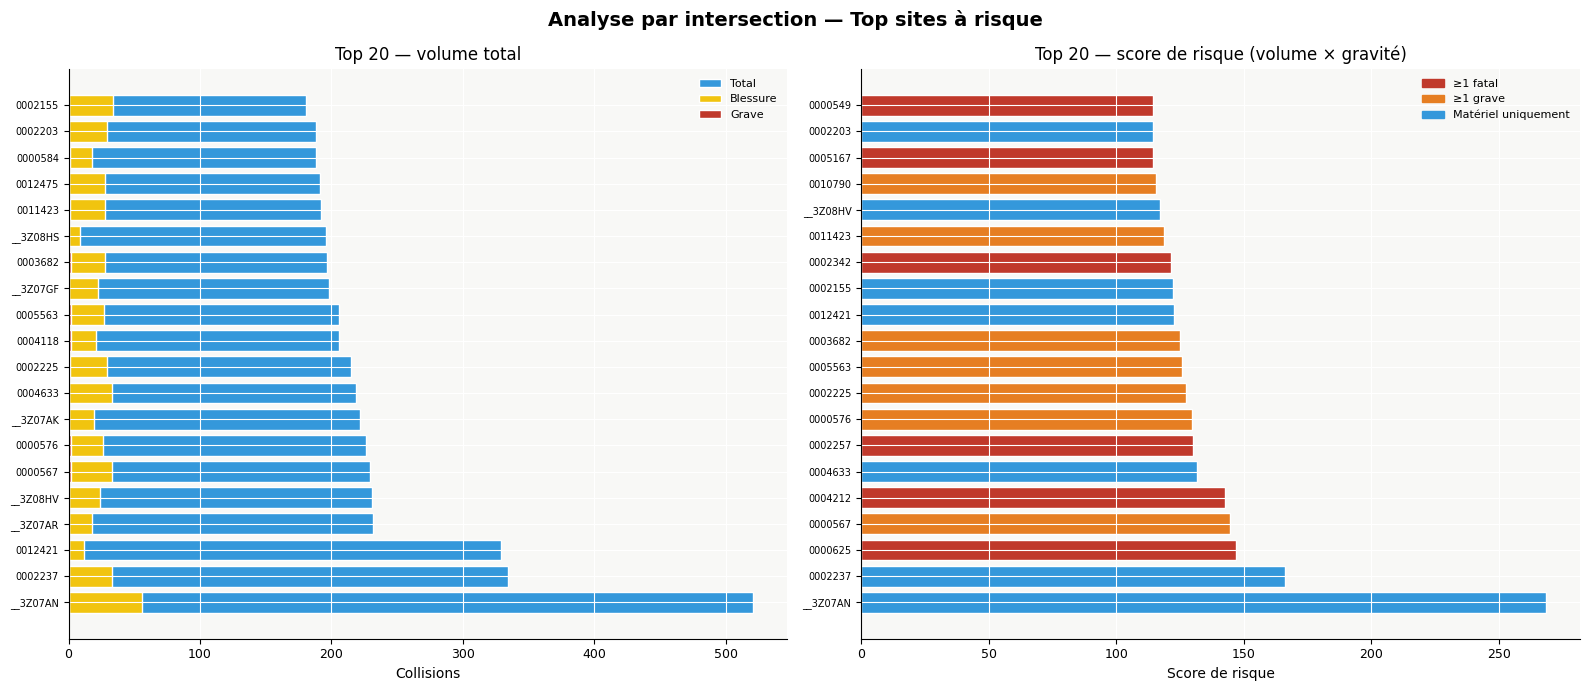

In [29]:
fig5, axes = plt.subplots(1, 2, figsize=(16,7))
fig5.suptitle("Analyse par intersection — Top sites à risque", fontsize=14, fontweight='bold')

ax = axes[0]
top20_vol = inter_stats.nlargest(20,'total')
ax.barh(range(20), top20_vol['total'].values,     color=PALETTE['materiel'], edgecolor='white', label='Total')
ax.barh(range(20), top20_vol['n_blessure'].values, color=PALETTE['blessure'], edgecolor='white', label='Blessure')
ax.barh(range(20), top20_vol['n_severe'].values,   color=PALETTE['fatal'],    edgecolor='white', label='Grave')
ax.set_yticks(range(20)); ax.set_yticklabels(top20_vol['Geo_ID'].values, fontsize=7)
ax.set_title("Top 20 — volume total")
ax.set_xlabel("Collisions"); ax.legend(frameon=False, fontsize=8)

ax = axes[1]
top20_risk = inter_stats[inter_stats['total']>=20].nlargest(20,'score_risque')
colors_risk = [PALETTE['fatal']    if row['n_fatal']>0 else
               PALETTE['severe']   if row['n_severe']>0 else
               PALETTE['materiel'] for _,row in top20_risk.iterrows()]
ax.barh(range(len(top20_risk)), top20_risk['score_risque'].values, color=colors_risk, edgecolor='white')
ax.set_yticks(range(len(top20_risk))); ax.set_yticklabels(top20_risk['Geo_ID'].values, fontsize=7)
ax.set_title("Top 20 — score de risque (volume × gravité)")
ax.set_xlabel("Score de risque")
ax.legend(handles=[
    mpatches.Patch(color=PALETTE['fatal'],    label='≥1 fatal'),
    mpatches.Patch(color=PALETTE['severe'],   label='≥1 grave'),
    mpatches.Patch(color=PALETTE['materiel'], label='Matériel uniquement'),
], frameon=False, fontsize=8)

plt.tight_layout()
plt.savefig('fig5_intersections.png', dpi=150, bbox_inches='tight')
plt.show()

### Synthèse — Faits clés

| Dimension | Observation | Module |
|-----------|-------------|--------|
| **Géographie** | 14 889 intersections, clusters denses en centre-ville | A — Hotspots |
| **Gravité** | 965 graves, 170 fatales (1.0%) | B, C, F |
| **Hiver** | 16.7% en conditions hivernales actives | D — Segmentation |
| **Vulnérables** | Taux blessure piétons **96.9%** vs 12.8% autres | E |
| **Top intersection** | `__3Z07AN` : 521 collisions, score 268 | F — Anomalies |